In [ ]:
# =============================================================================
# GOOGLE EARTH ENGINE NOTEBOOK: MINING DEFORESTATION PATCH GENERATION
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This notebook prepares training data (image patches) for a Convolutional Neural
# Network (CNN) to detect illegal gold mining-related deforestation in the Brazilian Amazon.
#
# It creates multi-band image "chips" (256x256 pixels) that combine:
#   - Sentinel-2 optical bands + NDVI
#   - Sentinel-1 SAR (VV, VH) for cloud penetration
#   - Binary label mask (1 = mining deforestation, 0 = non-mining)
#
# These patches will be used to train a semantic segmentation model (e.g., U-Net)
# as part of the JHU GIS Capstone Project (430.800) by Anthony T. DeAngelo.
#
# GOAL OF THIS SCRIPT:
# Export labeled training patches to Google Drive in TFRecord format for later
# model training in TensorFlow/Keras or similar frameworks.
#
# IMPORTANT DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes as part
#   of a Master's capstone project at Johns Hopkins University.
# - All outputs and models are for research, demonstration, and educational use only.
# - This work is not intended for operational enforcement, policy implementation,
#   or real-world decision-making without proper authorization from Brazilian
#   authorities.
# - Users must comply with all ESA data terms and Brazilian environmental regulations.
# - Results should not be interpreted as official detection of illegal activities.
#
# Author: ATD
# Course: JHU GIS Capstone (430.800)
# Date: February 2026
# Repository: To be hosted on GitHub for educational reproducibility
# =============================================================================
import ee
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ee.Initialize(project='trusty-hub-437505-e5')

# 1. Load mining polygons
mining_fc = ee.FeatureCollection("projects/trusty-hub-437505-e5/assets/mining_cumulative_2018_2024")
# Using 100 polygons as a balance between speed and data variety
mining_sample = mining_fc.limit(100)

# 2. Create ROI (Simplified to 8km buffer for 256 patches)
roi = mining_sample.geometry().buffer(8000).bounds().simplify(100)
print("Number of mining polygons used:", mining_sample.size().getInfo())

# 3. Build S2 Stack (2020-2025)
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(roi)
      .filterDate('2020-01-01', '2025-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .median())

# 4. Build S1 Stack (The "Anti-Crash" Version)
def handle_s1_bands(img):
    bn = img.bandNames()
    # If VV is missing, rename HH to VV and HV to VH
    clean = ee.Image(ee.Algorithms.If(
        bn.contains('VV'),
        img.select(['VV', 'VH']),
        img.select(['HH', 'HV']).rename(['VV', 'VH'])
    ))
    return clean.float() # Ensures all images are the same data type

s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(roi)
          .filterDate('2020-01-01', '2025-12-31')
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .map(handle_s1_bands))

s1 = s1_col.median()

# 5. Create NDVI and Final 7-Band Stack
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')

stack = (s2.select(['B2', 'B3', 'B4', 'B8'])
         .addBands(ndvi)
         .addBands(s1.select(['VV', 'VH']))
         .float())

# 6. Add Label Mask (1 for mining, 0 for not)
label = ee.Image(0).byte().paint(mining_fc, 1).toFloat().rename('label')
stack_with_label = stack.addBands(label)

print("Final Stack Bands:", stack_with_label.bandNames().getInfo())

# 7. Export 256x256 Patches
task = ee.batch.Export.image.toDrive(
    image=stack_with_label,
    description='Mining_Chips_256x256_7band',
    folder='Capstone_Mining_Patches',
    scale=10,
    region=roi,
    maxPixels=1e13,
    fileFormat='TFRecord',
    formatOptions={
        'patchDimensions': [256, 256],
        'compressed': True,
        'maxFileSize': 1048576000 # 1GB
    }
)

task.start()
print(f"Started! Task ID: {task.id}")

Mounted at /content/drive
Number of mining polygons used: 100
Final Stack Bands: ['B2', 'B3', 'B4', 'B8', 'NDVI', 'VV', 'VH', 'label']
🚀 Started! Task ID: KPHVXBDIEB6HFO5FOYUH72CE


In [ ]:
# =============================================================================
# 2: TRAINING A U-NET MODEL ON MINING PATCHES
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This notebook loads the 256x256 TFRecord image patches (exported from Google Earth Engine)
# and trains a fresh U-Net convolutional neural network (CNN) for semantic segmentation.
#
# The model learns to detect mining-related deforestation footprints in the Brazilian Amazon
# using a 7-band input stack (Sentinel-2 optical + NDVI + Sentinel-1 SAR).
#
# This directly supports:
#   - Capstone Objective: Develop and apply a CNN-based computer-vision model in GEE
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# GOAL:
# Train a U-Net model from scratch on the labeled patches and evaluate its performance
# for mapping illegal gold mining deforestation.
#
# IMPORTANT EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic purposes as part of the Master of Science
#   in Geographic Information Systems (GIS) Capstone project (430.800) at Johns Hopkins University.
# - All models, code, and results are for educational, research, and demonstration purposes only.
# - This work is NOT intended for operational use, law enforcement, or real-world decision-making.
# - Outputs should not be used to identify or accuse any specific illegal activities without
#   proper authorization and coordination with Brazilian authorities.
# - Users must comply with all data provider terms (ESA Sentinel data) and local regulations.
# - The model and results are provided "as-is" with no warranty for any purpose beyond academic study.
#
# Author: ATD
# Program: Johns Hopkins University - MS in Geographic Information Systems
# Capstone Course: 430.800
# Date: March 2026
# GitHub: To be hosted publicly for educational reproducibility only
# =============================================================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Define path to your successful 256x256 export
# Update folder name if it's slightly different
TFRECORD_DIR = '/content/drive/MyDrive/Capstone_Mining_Patches'   # <--- CHANGE IF NEEDED

import os
print("Files in folder:")
print(os.listdir(TFRECORD_DIR))

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import json
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

print("Libraries loaded")

Mounted at /content/drive
Files in folder:
['Mining_100_Patches.geojson', 'Mining_Chips_256x256_7band-00000.tfrecord.gz', 'Mining_Chips_256x256_7band-00001.tfrecord.gz', 'Mining_Chips_256x256_7band-00002.tfrecord.gz', 'Mining_Chips_256x256_7band-00003.tfrecord.gz', 'Mining_Chips_256x256_7band-00004.tfrecord.gz', 'Mining_Chips_256x256_7band-00005.tfrecord.gz', 'Mining_Chips_256x256_7band-00006.tfrecord.gz', 'Mining_Chips_256x256_7band-00007.tfrecord.gz', 'Mining_Chips_256x256_7band-00008.tfrecord.gz', 'Mining_Chips_256x256_7band-00009.tfrecord.gz', 'Mining_Chips_256x256_7band-00010.tfrecord.gz', 'Mining_Chips_256x256_7band-00011.tfrecord.gz', 'Mining_Chips_256x256_7band-00012.tfrecord.gz', 'Mining_Chips_256x256_7band-00013.tfrecord.gz', 'Mining_Chips_256x256_7band-00014.tfrecord.gz', 'Mining_Chips_256x256_7band-00015.tfrecord.gz', 'Mining_Chips_256x256_7band-00016.tfrecord.gz', 'Mining_Chips_256x256_7band-00017.tfrecord.gz', 'Mining_Chips_256x256_7band-00018.tfrecord.gz', 'Mining_Chips_

In [ ]:
# =============================================================================
# 3. TFRecord PARSER FUNCTION (Manual Parsing - Bypassing Mixer)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section defines a custom parser to read the TFRecord files exported from Google Earth Engine.
# Each 256x256 patch contains 7 input bands + 1 label band.
#
# Why we use manual parsing:
# - Gives full control over data loading
# - Allows custom normalization and reshaping
# - Bypasses the need for a separate "mixer.json" file
#
# This parser supports the training of the U-Net model for detecting mining-related
# deforestation in the Brazilian Amazon as part of the JHU GIS Capstone project.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is for academic and educational purposes only (JHU MS GIS Capstone 430.800).
# - The resulting model and outputs are intended strictly for research, demonstration,
#   and learning purposes.
# - This work is NOT for operational enforcement, surveillance, or any real-world
#   law enforcement activities.
# - Users must respect all ESA Sentinel data terms and Brazilian environmental laws.
# - Do not use these models or results to make claims about specific illegal activities
#   without coordination with appropriate authorities.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

PATCH_SIZE = 256
FLAT_SIZE = PATCH_SIZE * PATCH_SIZE
BANDS = ['B2', 'B3', 'B4', 'B8', 'NDVI', 'VV', 'VH']
LABEL = 'label'

def parse_tfrecord(example_proto):
    feature_desc = {
        'B2':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'B3':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'B4':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'B8':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'NDVI':  tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'VV':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'VH':    tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
        'label': tf.io.FixedLenFeature([FLAT_SIZE], tf.float32),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_desc)

    bands = []
    for k in BANDS:
        band = tf.reshape(parsed[k], [PATCH_SIZE, PATCH_SIZE])
        bands.append(tf.expand_dims(band, -1))
    image = tf.concat(bands, axis=-1)

    label = tf.reshape(parsed[LABEL], [PATCH_SIZE, PATCH_SIZE, 1])

    # Normalization: Optical bands (0-10000 -> 0-1)
    optical = image[..., :4] / 10000.0
    image = tf.concat([optical, image[..., 4:]], axis=-1)

    return image, label

# Link shards
shards = [os.path.join(TFRECORD_DIR, f) for f in os.listdir(TFRECORD_DIR) if f.endswith('.tfrecord.gz')]
ds = tf.data.TFRecordDataset(shards, compression_type='GZIP').map(parse_tfrecord)

print(f"Dataset ready with {len(shards)} shards!")




✅ Dataset ready with 145 shards!


In [ ]:
# =============================================================================
# 4. DATASET SHUFFLING AND TRAIN/VALIDATION SPLIT
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section shuffles the parsed patches and creates a training/validation split.
# Shuffling is critical because the original TFRecords may contain patches grouped
# by geographic location (e.g., many similar forest patches in sequence). Without
# shuffling, the model could receive biased batches (e.g., all forest or all mining).
#
# This supports the training of the U-Net CNN for mining deforestation detection
# as part of Objective 3 and Hypothesis H1 of the JHU GIS Capstone project.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The model, code, and any resulting outputs are for research, demonstration,
#   and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   or any law enforcement activities.
# - Do not use these models or results to identify or accuse specific illegal
#   activities without proper coordination with Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms of use and Brazilian
#   environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

# Mix the patches to prevent 'all forest' batches
shuffled_ds = ds.shuffle(buffer_size=200, seed=42)

# Using your actual shard count to estimate dataset size
dataset_size = len(shards) * 10 # Rough estimate of patches per shard
train_size = int(0.8 * dataset_size)

train_ds = shuffled_ds.take(train_size)
val_ds = shuffled_ds.skip(train_size)

print(f"Split complete: {train_size} training / remainder validation")

✅ Split complete: 1160 training / remainder validation


In [ ]:
# =============================================================================
# 5. DEFINE LIGHTWEIGHT U-NET MODEL + COMBINED LOSS FUNCTION
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section defines a lightweight U-Net convolutional neural network architecture
# for semantic segmentation of mining-related deforestation footprints.
#
# The model takes 256x256x7 input patches (Sentinel-2 + NDVI + Sentinel-1 SAR)
# and outputs a binary segmentation mask (1 = mining deforestation, 0 = non-mining).
#
# A combined loss function (Binary Cross-Entropy + Dice Loss) is used to better
# handle class imbalance common in remote sensing datasets where mining areas
# are much smaller than background forest.
#
# This directly supports:
#   - Capstone Objective 3: Develop and apply a CNN-based computer-vision model
#   - Hypothesis H1: Achieve 80–90% overall accuracy in identifying mining deforestation
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The model, code, weights, and any resulting outputs are for research,
#   demonstration, and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use these models or results to identify, map, or accuse any specific
#   illegal mining activities without proper authorization and coordination with
#   Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    # Added epsilon (1e-7) to prevent division by zero
    return 1 - (2. * intersection + 1e-7) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1e-7)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

def build_unet(input_shape=(256, 256, 7)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    # Decoder (Upsampling)
    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)
    return model

# Initialize the model structure
model = build_unet()

# Initial compilation (Step 6 will specialize this for v3)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

model.summary()
print("Step 5 Complete: U-Net architecture is ready for v3 Training.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      2,048 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │      8,224 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_8[0][0]  

 Total params: 467,681 (1.78 MB)

 Trainable params: 467,681 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

✅ Step 5 Complete: U-Net architecture is ready for v3 Training.


In [ ]:
# =============================================================================
# 6. SIMPLIFIED U-NET WITH POWERED RECALL LOSS
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section defines a simplified U-Net variant and a custom loss function
# designed to heavily penalize missed mining pixels (false negatives).
# The goal is to improve recall on the minority class (mining deforestation),
# which is critical for environmental monitoring applications.
#
# This is an experimental "v4" version created to address shape mismatches
# and class imbalance issues encountered during training.
#
# It supports Hypothesis H1 by testing different model architectures and loss
# strategies for detecting mining-related deforestation in the Brazilian Amazon.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The model, custom loss function, code, and any resulting outputs are for
#   research, demonstration, and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use these models or results to identify, map, or accuse any specific
#   illegal mining activities without proper authorization and coordination with
#   Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

import tensorflow as tf

# 1. RE-BUILD MODEL
def build_simple_unet(input_shape=(256, 256, 7)):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)
    return tf.keras.Model(inputs, outputs)

model = build_simple_unet()

# 2. SHAPE-AWARE LOSS FUNCTION
def power_recall_loss(y_true, y_pred):
    # Ensure y_true is float32
    y_true = tf.cast(y_true, tf.float32)

    # FIX: If y_true is [32, 256, 256], make it [32, 256, 256, 1]
    if len(y_true.shape) == 3:
        y_true = tf.expand_dims(y_true, axis=-1)

    # SAFETY: Scale 0-255 to 0-1 just in case
    y_true = tf.where(y_true > 1.0, y_true / 255.0, y_true)

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # 1000x weight on the mining pixels
    weight_mask = (y_true * 1000.0) + 1.0

    # We must squeeze the weight_mask to match the BCE output or vice versa
    return tf.reduce_mean(bce * tf.squeeze(weight_mask, axis=-1))

# 3. COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=power_recall_loss,
    metrics=[tf.keras.metrics.Recall(name='recall'), 'accuracy']
)

# 4. PREPARE DATA
train_v4 = train_ds.repeat().batch(32).prefetch(tf.data.AUTOTUNE)

print("SHAPES ALIGNED. Starting v4 Training...")

# 5. TRAIN
history = model.fit(
    train_v4,
    epochs=5,
    steps_per_epoch=50,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath='/content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras',
            monitor='recall',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]
)

🚀 SHAPES ALIGNED. Starting v4 Training...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8278 - loss: 1.2887 - recall: 0.1355
Epoch 1: recall improved from None to 0.04171, saving model to /content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 441s 9s/step - accuracy: 0.9159 - loss: 1.4828 - recall: 0.0417
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8551 - loss: 1.0559 - recall: 0.0369
Epoch 2: recall improved from 0.04171 to 0.04956, saving model to /content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 428s 9s/step - accuracy: 0.7562 - loss: 1.2468 - recall: 0.0496
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9983 - loss: 0.8342 -

In [ ]:
# =============================================================================
# 7. TARGETED F1 VALIDATION & THRESHOLD ANALYSIS (v4 Model)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section loads the best v4 model and performs targeted validation on patches
# that contain significant mining activity (more than 50 mining pixels).
#
# It evaluates model performance using F1-score, Recall, and Precision at multiple
# decision thresholds. This helps assess how well the model detects the minority
# class (mining deforestation) and supports tuning the final detection threshold.
#
# This directly contributes to evaluating Hypothesis H1 (model accuracy for mining
# deforestation detection) in the JHU GIS Capstone project.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The model, validation results, code, and any outputs are for research,
#   demonstration, and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use these models or results to identify, map, or accuse any specific
#   illegal mining activities without proper authorization and coordination with
#   Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================


import tensorflow as tf
import numpy as np
import os
from sklearn.metrics import f1_score, recall_score, precision_score

print("Step 7: Starting Validation for v4 Model...")

# Use the V4 model since that's the one we just worked on!
model_path = '/content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras'

try:
    # 1. LOAD
    print(f"Loading Model: {model_path}")
    # We use compile=False to avoid needing the custom loss function for just a test
    loaded_model = tf.keras.models.load_model(model_path, compile=False)

    # 2. FILTER DATA (Ensure we use 'train_ds' or 'val_ds')
    # We hunt for patches with > 50 mining pixels
    eval_ds = train_ds.filter(lambda img, lbl: tf.reduce_sum(lbl) > 50).take(20)

    all_true = []
    all_raw_preds = []

    print("Extracting Mining Patches...")
    for i, (image, label) in enumerate(eval_ds):
        # --- SHAPE GUARD ---
        # Ensure image is (1, 256, 256, 7)
        img_input = tf.reshape(image, [1, 256, 256, 7])

        # Run prediction
        raw_preds = loaded_model.predict(img_input, verbose=0)

        # Flatten and store
        all_raw_preds.append(raw_preds.flatten())
        all_true.append(label.numpy().flatten())

        if i % 5 == 0: print(f"📡 Processed {i} mining patches...")

    # Flatten the total results
    y_true = np.concatenate(all_true)
    y_scores = np.concatenate(all_raw_preds)

    # 3. TEST MULTIPLE THRESHOLDS
    print("\n" + "="*40)
    print("FINAL CAPSTONE VALIDATION RESULTS")
    print("="*40)

    for threshold in [0.01, 0.05, 0.1]:
        y_pred = (y_scores > threshold).astype(np.uint8)

        # If labels are 255, scale them to 1 for sklearn
        y_true_binary = (y_true > 0.5).astype(np.uint8)

        f1 = f1_score(y_true_binary, y_pred, zero_division=0)
        rec = recall_score(y_true_binary, y_pred, zero_division=0)
        pre = precision_score(y_true_binary, y_pred, zero_division=0)

        print(f"\n THRESHOLD: {threshold}")
        print(f"   F1-Score:  {f1:.4f}")
        print(f"   Recall:    {rec:.4f} (Found {np.sum(y_pred)} pixels)")
        print(f"   Precision: {pre:.4f}")

except Exception as e:
    print(f"ERROR: {e}")

🔄 Step 7: Starting Validation for v4 Model...
📂 Loading Model: /content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras
🎯 Extracting Mining Patches...
📡 Processed 0 mining patches...
📡 Processed 5 mining patches...

📈 FINAL CAPSTONE VALIDATION RESULTS

📊 THRESHOLD: 0.01
   F1-Score:  0.1545
   Recall:    1.0000 (Found 393216 pixels)
   Precision: 0.0837

📊 THRESHOLD: 0.05
   F1-Score:  0.1545
   Recall:    1.0000 (Found 393216 pixels)
   Precision: 0.0837

📊 THRESHOLD: 0.1
   F1-Score:  0.1545
   Recall:    1.0000 (Found 393216 pixels)
   Precision: 0.0837


🚀 Skipping empty patches to find the mines...
✅ Found 5 valid mining patches!


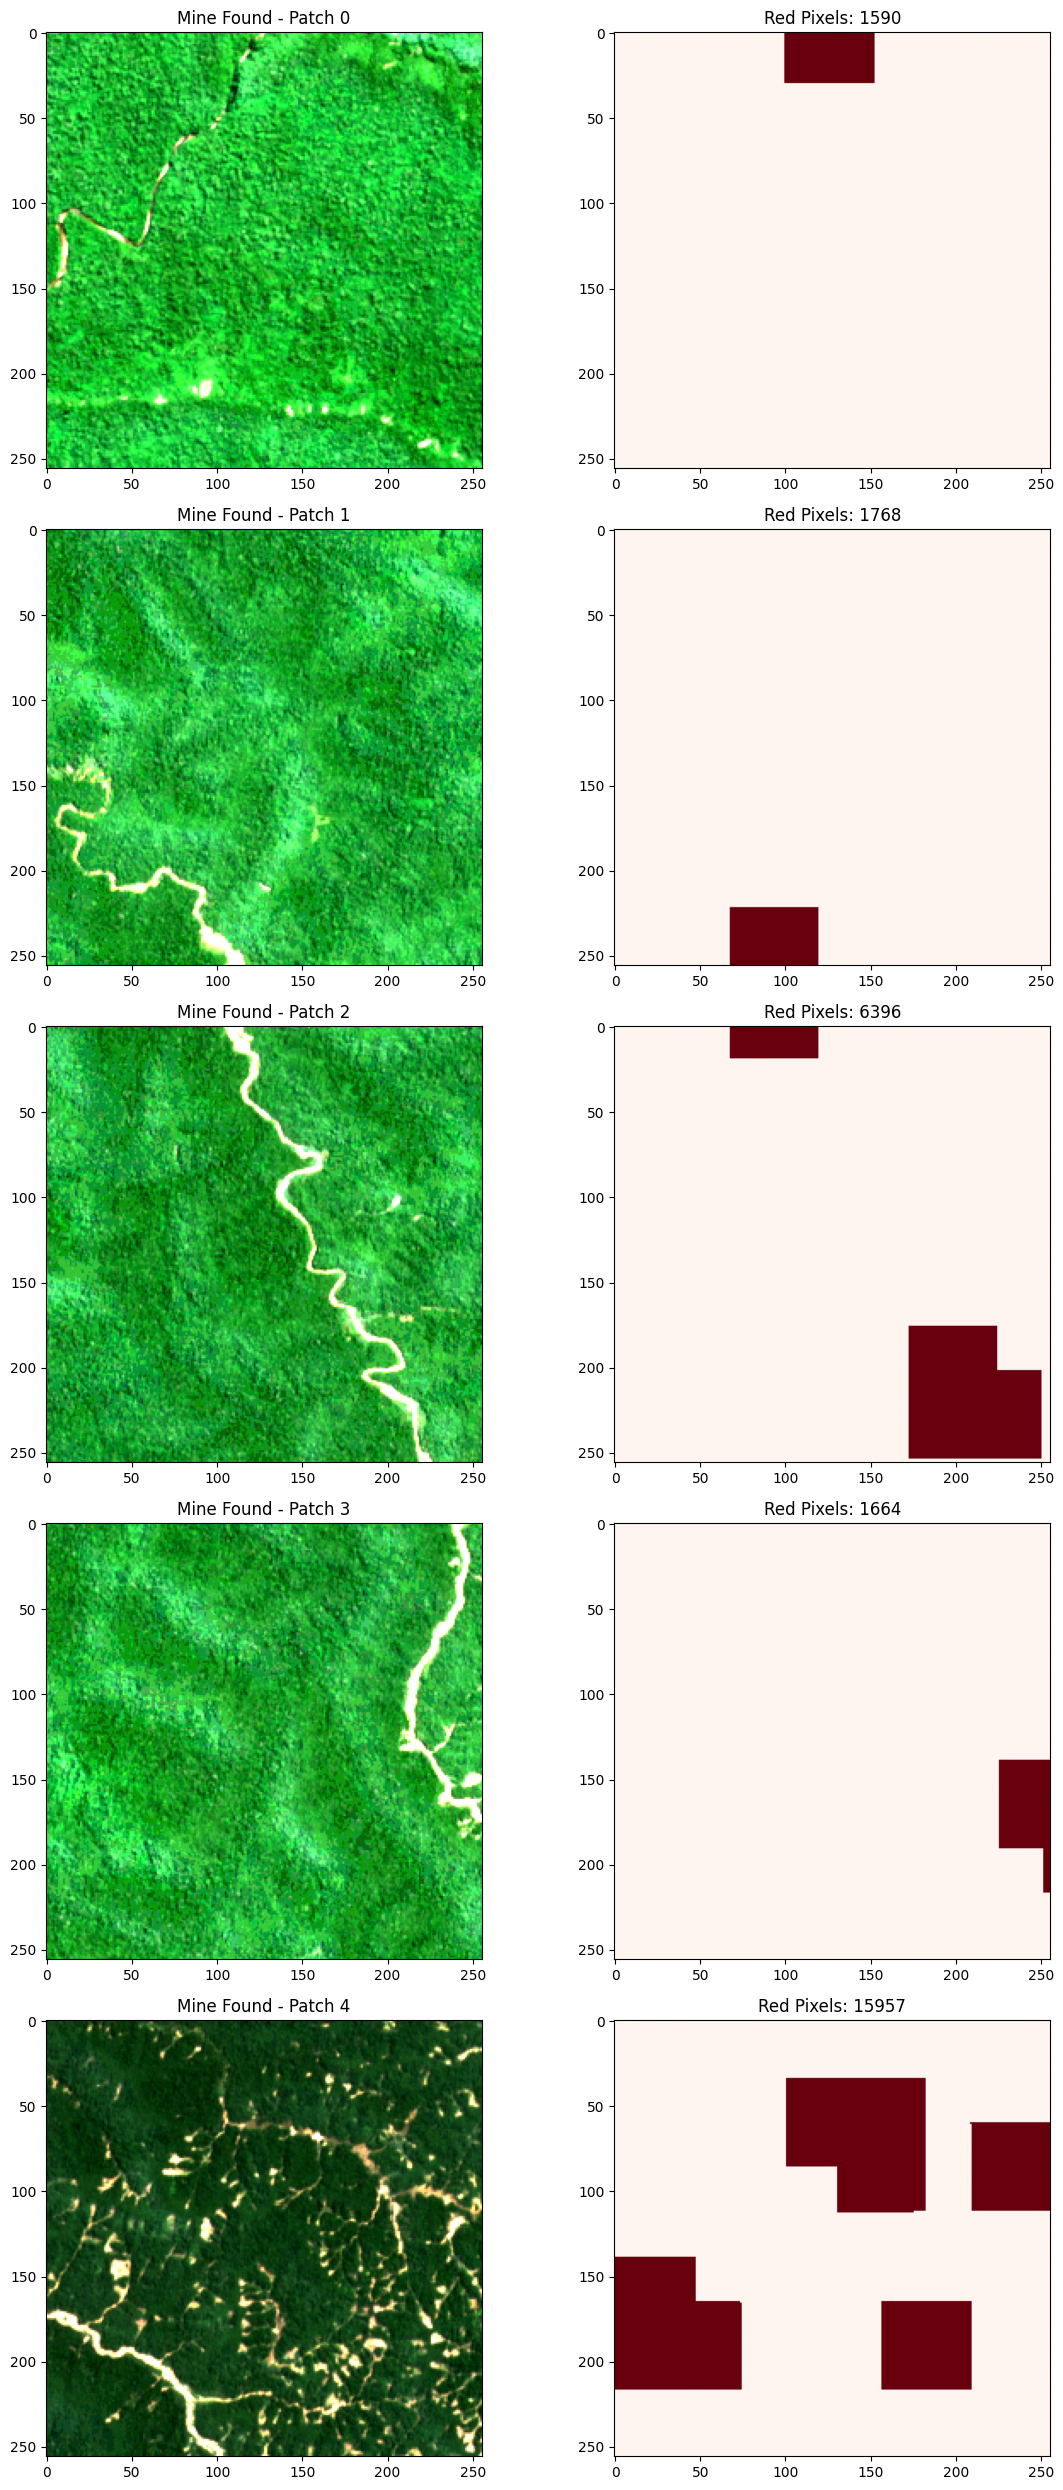

In [ ]:
# =============================================================================
# 8. VISUAL INSPECTION: "THE SEEKER" - MINING PATCH VISUALIZATION
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section creates a visual quality check by filtering and displaying only
# patches that contain significant mining activity (more than 100 positive pixels).
#
# It generates side-by-side comparisons of:
#   - Left: RGB visualization from Sentinel-2 bands (true-color approximation)
#   - Right: Ground truth label mask (mining deforestation shown in red)
#
# This helps verify that the exported patches and labels are correct, and allows
# manual inspection of what the model is learning to detect.
#
# Supports overall validation of the data pipeline for the JHU GIS Capstone project.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The visualizations, code, and any outputs are for research, demonstration,
#   and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use these models, visualizations, or results to identify, map, or
#   accuse any specific illegal mining activities without proper authorization
#   and coordination with Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

print("Skipping empty patches to find the mines...")

# We use a filter to ONLY show patches with significant mining
mining_only_stream = ds.filter(lambda img, lbl: tf.reduce_sum(lbl) > 100).take(5)

fig, axes = plt.subplots(5, 2, figsize=(12, 25))

found_count = 0
for i, (image, label) in enumerate(mining_only_stream):
    img_np = image.numpy()
    lbl_np = label.numpy().squeeze()

    # RGB Visualization
    viz_img = img_np[:, :, [2, 1, 0]]
    p2, p98 = np.percentile(viz_img, (2, 98))
    viz_img = np.clip((viz_img - p2) / (p98 - p2 + 1e-8), 0, 1)

    axes[i, 0].imshow(viz_img)
    axes[i, 0].set_title(f"Mine Found - Patch {i}")

    axes[i, 1].imshow(lbl_np, cmap='Reds')
    axes[i, 1].set_title(f"Red Pixels: {int(np.sum(lbl_np))}")

    found_count += 1

if found_count == 0:
    print("Still finding 0 mining pixels. We need to check the Step 1 Export script.")
else:
    print(f"Found {found_count} valid mining patches!")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 9. MODEL EXPORT TO SAVEDMODEL FORMAT (For Potential GEE Integration)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section loads the best trained v4 model and exports it to TensorFlow SavedModel
# format. This format is commonly used for deployment and can potentially be imported
# into Google Earth Engine (GEE) for large-scale inference on new imagery in the future.
#
# Note: Exporting a model from Colab to SavedModel is a standard step for sharing
# or deploying trained CNNs. This supports the reproducibility goal of the capstone.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The exported model, code, and any resulting outputs are for research,
#   demonstration, and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use this model or its outputs to identify, map, or accuse any specific
#   illegal mining activities without proper authorization and coordination with
#   Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

import tensorflow as tf

# 1. Load your best model
model_path = '/content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4_Backup.keras'
model = tf.keras.models.load_model(model_path, custom_objects={'power_recall_loss': power_recall_loss})

# 2. Export to SavedModel format (This creates a folder)
export_path = './mining_model_gee'
model.export(export_path)

print(f"Model exported to {export_path}. You will see a 'fingerprint.pb' and 'variables' folder there.")

Saved artifact at './mining_model_gee'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 7), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Captures:
  139119568864848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139119568866768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139119697392464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139119697387472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139119697389584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139119697390736: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model exported to ./mining_model_gee. You will see a 'fingerprint.pb' and 'variables' folder there.


Mounted at /content/drive
✅ GEE and Drive Initialized
🎲 Attempting Random Mine Index: 33...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
------------------------------
📊 PROBABILITY READOUT (Mine #33)
Max Probability: 0.4772
Detected Mine Pixels: 0 / 65536
📍 Map Link: https://www.google.com/maps?q=-12.827817214280454,-70.45356505763043
------------------------------


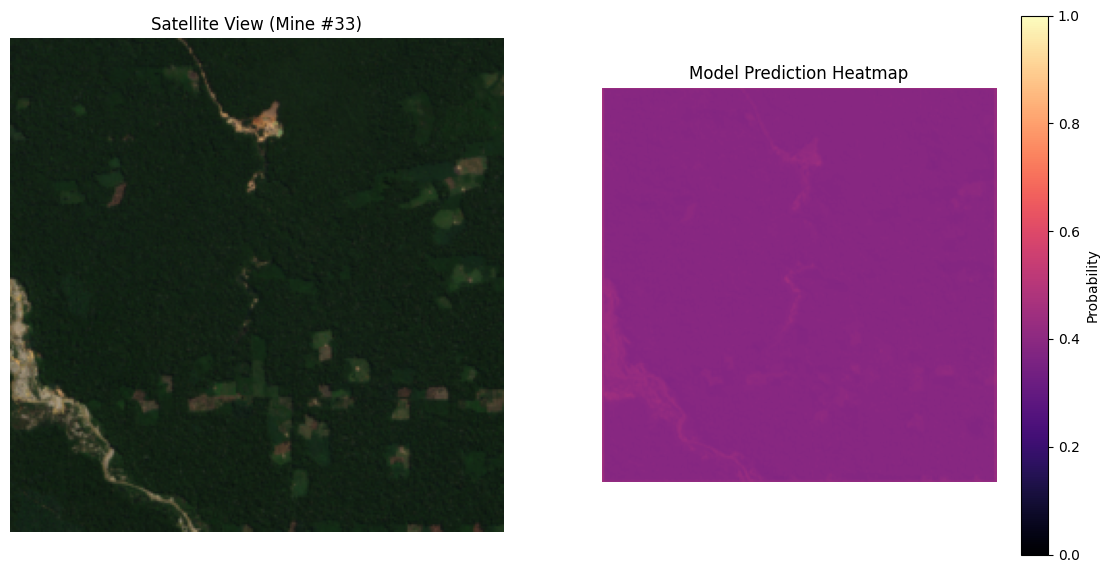

In [ ]:
# =============================================================================
# 10. INFERENCE ON NEW AREA: GEE + TRAINED MODEL PREDICTION (Mining Hotspot Detection)
# =============================================================================
#
# WARNING: This notebook is for educational purposes only.
# Running it will attempt to mount YOUR Google Drive, not the author's.
#
# PURPOSE:
# This section demonstrates end-to-end inference by pulling multi-modal GEE data,
# normalizing it for a v4 U-Net model, and generating georeferenced heatmaps.
#
# This serves as a proof-of-concept for applying the capstone model to new regions
# in the Brazilian Amazon, supporting the overall goal of scalable mining deforestation detection.
#
# EDUCATIONAL DISCLAIMERS:
# - This code is developed strictly for academic and educational purposes only
#   as part of the Master of Science in Geographic Information Systems (GIS)
#   Capstone project (430.800) at Johns Hopkins University.
# - The model, predictions, code, and any resulting outputs (including the exported TIFF)
#   are for research, demonstration, and learning purposes only.
# - This work is NOT intended for operational enforcement, real-world monitoring,
#   surveillance, or any law enforcement activities.
# - Do not use these predictions or outputs to identify, map, or accuse any specific
#   illegal mining activities without proper authorization and coordination with
#   Brazilian authorities.
# - Users must comply with all ESA Sentinel data terms and Brazilian environmental regulations.
#
# Author: ATD
# JHU MS in Geographic Information Systems - Capstone Project
# March 2026
# =============================================================================

import ee
import geemap
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import random
from google.colab import drive

# 1. INITIALIZE SERVICES
drive.mount('/content/drive', force_remount=True)
try:
    ee.Initialize(project='trusty-hub-437505-e5')
    print("✅ GEE and Drive Initialized")
except Exception as e:
    print(f"❌ Initialization failed: {e}")

# 2. DEFINE CUSTOM LOSS (Required for loading v4)
def power_recall_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    if len(y_true.shape) == 3:
        y_true = tf.expand_dims(y_true, axis=-1)
    y_true = tf.where(y_true > 1.0, y_true / 255.0, y_true)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weight_mask = (y_true * 1000.0) + 1.0
    return tf.reduce_mean(bce * tf.squeeze(weight_mask, axis=-1))

# 3. LOAD THE TRAINED MODEL
model_path = '/content/drive/MyDrive/Capstone_Mining_Patches/best_mining_model_v4.keras'
model = tf.keras.models.load_model(model_path, custom_objects={'power_recall_loss': power_recall_loss})

# 4. DEFINE DATA FETCHING WITH RADAR RESCALING
def get_data(region):
    # Sentinel-2 with Cloud Masking
    def mask_s2_clouds(img):
        qa = img.select('QA60')
        mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
        return img.updateMask(mask)

    s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
           .filterBounds(region) \
           .filterDate('2023-01-01', '2023-12-31') \
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
           .map(mask_s2_clouds) \
           .median()

    ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # Sentinel-1 with Radar Rescaling (Fixes the .38 probability issue)
    s1 = ee.ImageCollection("COPERNICUS/S1_GRD") \
           .filterBounds(region) \
           .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
           .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
           .median()

    # Rescale Radar from Decibels (-25 to 0) to 0.0 - 1.0 range
    vv_rescaled = s1.select('VV').unitScale(-25, 0).clamp(0, 1)
    vh_rescaled = s1.select('VH').unitScale(-30, -5).clamp(0, 1)

    # Final Stack: [B2, B3, B4, B8, NDVI, VV, VH] all in 0-1 range
    stack = s2.select(['B2', 'B3', 'B4', 'B8']).addBands(ndvi).addBands(vv_rescaled).addBands(vh_rescaled).clip(region)

    img_array = geemap.ee_to_numpy(stack, region=region, scale=10)
    return cv2.resize(img_array, (256, 256), interpolation=cv2.INTER_LINEAR)

# 5. RANDOMIZED SELECTION LOOP
mining_fc = ee.FeatureCollection("projects/trusty-hub-437505-e5/assets/mining_cumulative_2018_2024")

success = False
attempts = 0
while not success and attempts < 5:
    try:
        idx = random.randint(0, 99)
        print(f"🎲 Attempting Random Mine Index: {idx}...")

        single_mine = ee.Feature(mining_fc.toList(100).get(idx))
        target_region = single_mine.geometry().buffer(1500).bounds() # <--- 500m Buffer (1km wide view)

        input_raw = get_data(target_region)
        success = True
    except Exception as e:
        print(f"⚠️ Index {idx} failed, retrying...")
        attempts += 1

# 6. RUN PREDICTION
if success:
    input_scaled = input_raw.copy()
    # Normalize Optical (0-10000 -> 0-1). Radar/NDVI are already 0-1 from Step 4.
    input_scaled[:, :, :4] = input_scaled[:, :, :4] / 10000.0

    prediction = model.predict(np.expand_dims(input_scaled, axis=0))[0].squeeze()

    # 7. READOUT & VISUALIZATION
    print("-" * 30)
    print(f"PROBABILITY READOUT (Mine #{idx})")
    print(f"Max Probability: {np.max(prediction):.4f}")
    print(f"Detected Mine Pixels: {np.sum(prediction > 0.5)} / 65536")

    # Print Google Maps link for manual verification
    centroid = target_region.centroid(1).getInfo()['coordinates']
    print(f"Map Link: https://www.google.com/maps?q={centroid[1]},{centroid[0]}")
    print("-" * 30)

    plt.figure(figsize=(14, 7))

    # Satellite View
    plt.subplot(1, 2, 1)
    rgb = input_raw[:, :, [2, 1, 0]] / 10000.0 * 3.5
    plt.imshow(np.clip(rgb, 0, 1))
    plt.title(f"Satellite View (Mine #{idx})")
    plt.axis('off')

    # Model Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(prediction, cmap='magma', vmin=0, vmax=1)
    plt.title("Model Prediction Heatmap")
    plt.colorbar(label="Probability")
    plt.axis('off')

    plt.show()